<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Mini_projet_W3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- 1. EXPLORATION INITIALE ---
Téléchargement et décompression du fichier ZIP d'Apple...
Fichier chargé avec succès : Apple Stock Prices (1981 to 2023).csv

Aperçu des premières lignes :
                Open      High       Low     Close  Adj Close    Volume
Date                                                                   
1981-01-02  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1981-01-05  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
1981-01-06  0.144531  0.144531  0.143973  0.143973   0.112032  45158400

Nombre de valeurs manquantes par colonne :
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Période couverte : Du 1981-01-02 au 2023-01-27

Génération des graphiques...


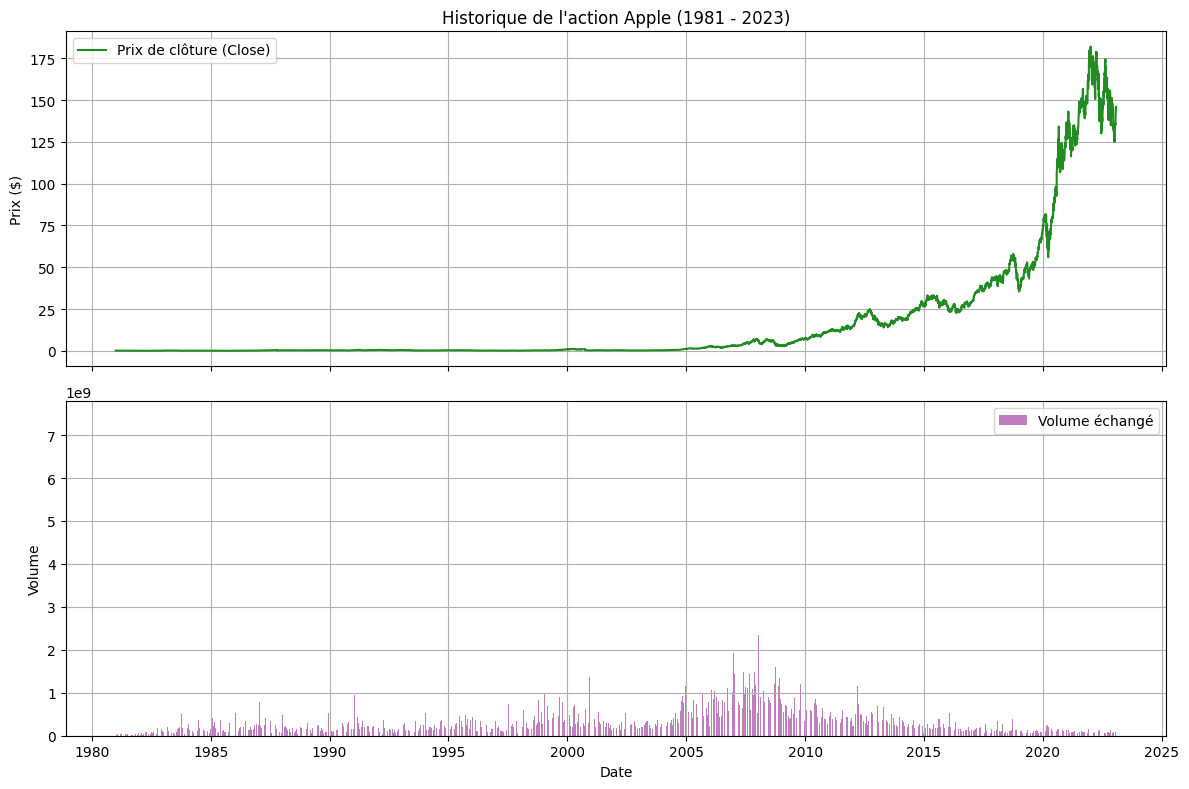

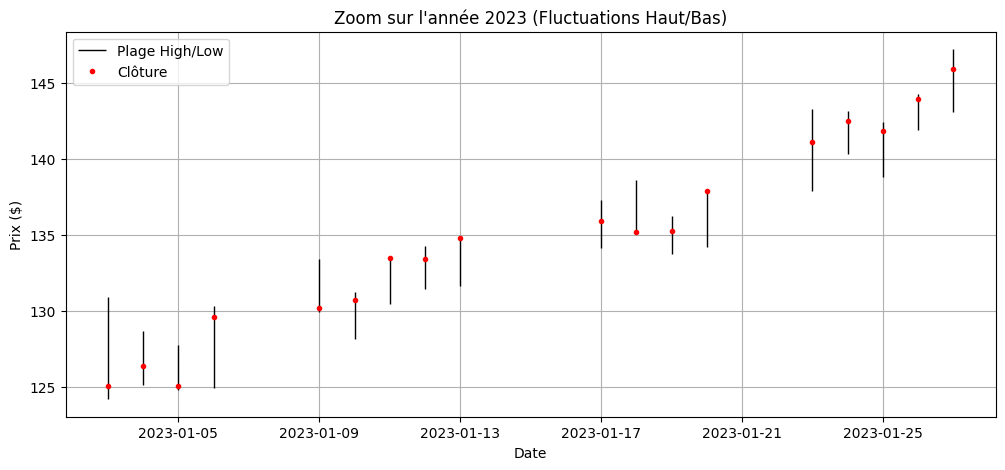


--- 3. ANALYSE STATISTIQUE ---
             Open       High        Low      Close        Volume
mean    16.689173  16.879955  16.500822  16.697362  3.275098e+08
median   0.488839   0.495536   0.480446   0.487701  2.145976e+08
std     35.450519  35.882848  35.031289  35.473912  3.378203e+08

--- 4. TESTS D'HYPOTHÈSES ---
Test T (Prix Moyens 2021 vs 2022) : P-value = 4.7097114017662864e-26
Test de normalité (Shapiro-Wilk sur les 4000 derniers jours) : P-value = 3.975605650710055e-37

--- 5. TECHNIQUES STATISTIQUES AVANCÉES (NUMPY) ---
Matrice de corrélation (NumPy) :
-> Corrélation entre Prix de Clôture et Volume : -0.2174
-> Corrélation entre Moyenne Mobile (50) et Volume : -0.2156


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
import urllib.request
import zipfile
import io

# ==========================================
# 1. INITIAL DATA EXPLORATION (TÉLÉCHARGEMENT & EXPLORATION)
# ==========================================
print("--- 1. EXPLORATION INITIALE ---")

# URL directe de votre fichier ZIP
url = "https://github.com/devtlv/Datasets-GEN-AI-Bootcamp/raw/refs/heads/main/Week%203/W3D4%20-%20Mini%20Project/Apple%20Stock%20Prices%20From%201981%20to%202023.zip"

print("Téléchargement et décompression du fichier ZIP d'Apple...")
# Téléchargement du ZIP et ouverture en mémoire
response = urllib.request.urlopen(url)
zip_file = zipfile.ZipFile(io.BytesIO(response.read()))

# Extraction du premier fichier CSV trouvé dans l'archive
csv_filename = [f for f in zip_file.namelist() if f.endswith('.csv')][0]
with zip_file.open(csv_filename) as f:
    df = pd.read_csv(f)

print(f"Fichier chargé avec succès : {csv_filename}")

# Conversion de la colonne Date et configuration comme Index
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df.set_index('Date', inplace=True)

# Vérification des types et valeurs manquantes
print("\nAperçu des premières lignes :")
print(df.head(3))

print("\nNombre de valeurs manquantes par colonne :")
print(df.isnull().sum())

print(f"\nPériode couverte : Du {df.index.min().date()} au {df.index.max().date()}")


# ==========================================
# 2. DATA VISUALIZATION (VISUALISATION)
# ==========================================
print("\nGénération des graphiques...")

# Graphique 1 : Prix de clôture (Close) et Volume au cours du temps
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(df.index, df['Close'], color='forestgreen', label='Prix de clôture (Close)')
ax1.set_title('Historique de l\'action Apple (1981 - 2023)')
ax1.set_ylabel('Prix ($)')
ax1.legend()
ax1.grid(True)

ax2.bar(df.index, df['Volume'], color='purple', alpha=0.5, label='Volume échangé')
ax2.set_ylabel('Volume')
ax2.set_xlabel('Date')
ax2.legend()
ax2.grid(True)
plt.tight_layout()
plt.show()

# Graphique 2 : Graphique "High / Low" simplifié (Zoom sur l'année 2023)
df_2023 = df.loc['2023']
plt.figure(figsize=(12, 5))
plt.vlines(df_2023.index, df_2023['Low'], df_2023['High'], color='black', linewidth=1, label='Plage High/Low')
plt.plot(df_2023.index, df_2023['Close'], color='red', marker='.', linestyle='', label='Clôture')
plt.title('Zoom sur l\'année 2023 (Fluctuations Haut/Bas)')
plt.xlabel('Date')
plt.ylabel('Prix ($)')
plt.legend()
plt.grid(True)
plt.show()


# ==========================================
# 3. STATISTICAL ANALYSIS (ANALYSE STATISTIQUE)
# ==========================================
print("\n--- 3. ANALYSE STATISTIQUE ---")

# Statistiques clés (Moyenne, Médiane, Écart-type)
colonnes_cles = ['Open', 'High', 'Low', 'Close', 'Volume']
statistiques = df[colonnes_cles].describe().loc[['mean', '50%', 'std']]
statistiques.rename(index={'50%': 'median'}, inplace=True)
print(statistiques)

# Analyse des prix avec une moyenne mobile (rolling) sur 50 jours
df['MA_50'] = df['Close'].rolling(window=50).mean()


# ==========================================
# 4. HYPOTHESIS TESTING (TESTS D'HYPOTHÈSES)
# ==========================================
print("\n--- 4. TESTS D'HYPOTHÈSES ---")

# T-Test : Comparaison des prix moyens entre deux années complètes (ex: 2021 vs 2022)
prix_2021 = df.loc['2021', 'Close'].dropna()
prix_2022 = df.loc['2022', 'Close'].dropna()

t_stat, p_val_t = stats.ttest_ind(prix_2021, prix_2022, equal_var=False)
print(f"Test T (Prix Moyens 2021 vs 2022) : P-value = {p_val_t}")

# Distribution des rendements quotidiens (Daily Returns)
df['Daily_Return'] = df['Close'].pct_change()
rendements_propres = df['Daily_Return'].dropna()

# Test de normalité de Shapiro-Wilk (Échantillon de taille max 5000 pour éviter les limites de scipy)
shapiro_stat, p_val_norm = stats.shapiro(rendements_propres.tail(4000))
print(f"Test de normalité (Shapiro-Wilk sur les 4000 derniers jours) : P-value = {p_val_norm}")


# ==========================================
# 5. ADVANCED STATISTICAL TECHNIQUES (BONUS NUMPY)
# ==========================================
print("\n--- 5. TECHNIQUES STATISTIQUES AVANCÉES (NUMPY) ---")

# Moyenne mobile 20 jours calculée via NumPy (convolve)
fenetre = 20
poids = np.ones(fenetre) / fenetre
# Note : mode='valid' supprime les bords pour éviter les distorsions
ma_20_numpy = np.convolve(df['Close'].dropna(), poids, mode='valid')

# Matrice de corrélation de Pearson avec NumPy
df_clean = df[['Close', 'Volume', 'MA_50']].dropna()
matrice_corr = np.corrcoef(df_clean.T)

print("Matrice de corrélation (NumPy) :")
print(f"-> Corrélation entre Prix de Clôture et Volume : {matrice_corr[0, 1]:.4f}")
print(f"-> Corrélation entre Moyenne Mobile (50) et Volume : {matrice_corr[2, 1]:.4f}")
